# Spotify Listening Behavior Analysis

## Project Overview

This project analyzes long-term Spotify listening history to understand music consumption behavior, engagement patterns, artist loyalty, and listening session types.

The analysis focuses on behavioral analytics rather than audio features, using real streaming history data to explore questions such as:

- When does listening activity peak?
- How does skip behavior change by time of day?
- How have artist preferences evolved over time?
- Are there distinct listening session patterns?
- Can listening sessions be segmented into behavioral archetypes?

The goal is to demonstrate data cleaning, feature engineering, exploratory data analysis, session analytics, clustering, and data storytelling using Python.

In [7]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Display settings
pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Loading the Cleaned Dataset

The raw Spotify JSON files were previously merged, cleaned, and saved as a processed CSV file.  
This notebook uses the cleaned dataset to focus on analysis and presentation.

In [8]:
df = pd.read_csv("../data/processed/spotify_cleaned.csv")

df.head()

C:\Users\lerma\AppData\Local\Temp\ipykernel_30864\4049600150.py:1: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/spotify_cleaned.csv")


,ts,platform,ms_played,conn_country,ip_addr,track_name,artist_name,album_name,spotify_track_uri,episode_name,episode_show_name,spotify_episode_uri,audiobook_title,audiobook_uri,audiobook_chapter_uri,audiobook_chapter_title,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode,minutes_played,hour,day_name,month,year,date,time_diff,gap_minutes,new_session,session_id
0,2018-03-05 20:35:24+00:00,"Android OS 6.0 API 23 (LGE, LG-K430)",10095,IL,109.66.61.202,Gravity Of You,STARSET,Vessels,spotify:track:6gPUI1OD1FqEbekgCyR5YD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,playbtn,fwdbtn,True,False,False,NaN,False,0.168250,20,Monday,March,2018,2018-03-05,NaN,NaN,False,0
1,2018-03-05 20:35:29+00:00,"Android OS 6.0 API 23 (LGE, LG-K430)",0,IL,109.66.61.202,DIE FOR YOU,STARSET,Vessels,spotify:track:4cExQhQ0i34yZcoDsHFMV6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fwdbtn,fwdbtn,True,False,False,NaN,False,0.000000,20,Monday,March,2018,2018-03-05,0 days 00:00:05,0.083333,False,0
2,2018-03-05 20:35:29+00:00,"Android OS 6.0 API 23 (LGE, LG-K430)",2114,IL,109.66.61.202,Ricochet,STARSET,Vessels,spotify:track:1ocR8gUE4fBfNJZtBr0TFQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fwdbtn,fwdbtn,True,False,False,NaN,False,0.035233,20,Monday,March,2018,2018-03-05,0 days 00:00:00,0.000000,False,0
3,2018-03-05 20:56:00+00:00,"Android OS 6.0 API 23 (LGE, LG-K430)",28746,IL,37.142.162.69,Carnivore,STARSET,Transmissions,spotify:track:4j41Du0uMXJrfEY7Xe9CDO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fwdbtn,endplay,True,False,False,NaN,False,0.479100,20,Monday,March,2018,2018-03-05,0 days 00:20:31,20.516667,False,0
4,2018-03-05 20:56:16+00:00,"Android OS 6.0 API 23 (LGE, LG-K430)",11557,IL,109.66.61.202,Carnivore,STARSET,Transmissions,spotify:track:4j41Du0uMXJrfEY7Xe9CDO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,clickrow,fwdbtn,True,False,False,NaN,False,0.192617,20,Monday,March,2018,2018-03-05,0 days 00:00:16,0.266667,False,0


In [10]:
df.shape

(482859, 33)

## 2. Data Preparation & Sessionization

Several additional behavioral features were engineered from the original Spotify streaming history data.

This included:

- Converting timestamps into temporal features
- Calculating listening duration in minutes
- Extracting weekday and hourly listening patterns
- Detecting listening sessions using inactivity gaps
- Creating session-level engagement metrics

Listening sessions were defined using a 30-minute inactivity threshold between playback events.

In [11]:
# Quick overview of engineered columns
engineered_features = [
    'minutes_played',
    'hour',
    'day_name',
    'month',
    'year',
    'gap_minutes',
    'session_id'
]

df[engineered_features].head()

,minutes_played,hour,day_name,month,year,gap_minutes,session_id
0,0.168250,20,Monday,March,2018,NaN,0
1,0.000000,20,Monday,March,2018,0.083333,0
2,0.035233,20,Monday,March,2018,0.000000,0
3,0.479100,20,Monday,March,2018,20.516667,0
4,0.192617,20,Monday,March,2018,0.266667,0


### Session-Level Aggregation

To better understand listening behavior, playback events were grouped into listening sessions.

For each session, the following metrics were calculated:

- Total listening duration
- Number of tracks played
- Session duration
- Session start hour
- Skip rate

In [12]:
# Rebuild session-level analysis table
session_analysis = (
    df.groupby('session_id')
    .agg({
        'minutes_played': 'sum',
        'track_name': 'count',
        'ts': ['min', 'max'],
        'hour': 'first',
        'skipped': 'mean'
    })
)

# Flatten column names
session_analysis.columns = [
    'total_minutes',
    'tracks_played',
    'session_start',
    'session_end',
    'start_hour',
    'skip_rate'
]

# Convert skip rate to percentage
session_analysis['skip_rate'] *= 100

# Calculate session duration
session_analysis['session_duration_minutes'] = (
    pd.to_datetime(session_analysis['session_end']) -
    pd.to_datetime(session_analysis['session_start'])
).dt.total_seconds() / 60

session_analysis.head()

,total_minutes,tracks_played,session_start,session_end,start_hour,skip_rate,session_duration_minutes
session_id,,,,,,,
0,8.407967,20,2018-03-05 20:35:24+00:00,2018-03-05 21:40:07+00:00,20,0.0,64.716667
1,24.323317,8,2018-03-06 05:29:00+00:00,2018-03-06 05:54:39+00:00,5,0.0,25.650000
2,73.635117,26,2018-03-06 09:46:09+00:00,2018-03-06 11:19:55+00:00,9,0.0,93.766667
3,19.021467,8,2018-03-06 15:18:21+00:00,2018-03-06 15:34:33+00:00,15,0.0,16.200000
4,29.873883,15,2018-03-06 16:36:38+00:00,2018-03-06 17:07:27+00:00,16,0.0,30.816667


In [13]:
session_analysis.describe().round(2)

,total_minutes,tracks_played,start_hour,skip_rate,session_duration_minutes
count,9857.00,9857.00,9857.00,9857.00,9857.00
mean,76.80,48.99,12.03,15.78,84.26
std,82.82,59.82,4.86,24.08,91.15
min,0.00,1.00,0.00,0.00,0.00
25%,17.51,11.00,8.00,0.00,18.73
50%,51.64,31.00,12.00,0.00,56.22
75%,107.46,67.00,16.00,29.31,119.07
max,844.89,1313.00,23.00,100.00,910.73


## 3. Listening Behavior Patterns

This section explores how listening activity changes across time.

The analysis focuses on:

- Listening intensity by hour and weekday
- Peak engagement periods
- Skip behavior throughout the day
- General playback activity patterns

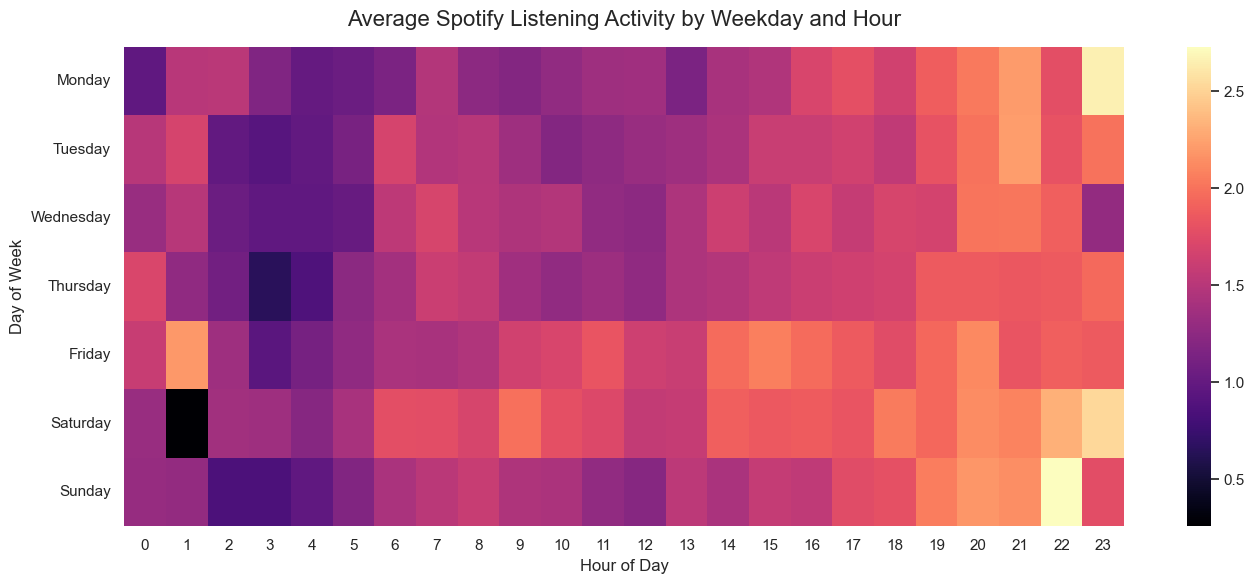

In [14]:
# Average listening minutes by weekday and hour
heatmap_data = (
    df.groupby(['day_name', 'hour'])['minutes_played']
    .mean()
    .unstack()
)

# Reorder weekdays
weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

heatmap_data = heatmap_data.reindex(weekday_order)

# Plot heatmap
plt.figure(figsize=(14, 6))

sns.heatmap(
    heatmap_data,
    cmap='magma'
)

plt.title(
    'Average Spotify Listening Activity by Weekday and Hour',
    fontsize=16,
    pad=15
)

plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')

plt.tight_layout()

plt.show()

### Insight

Listening activity was strongest during afternoon and evening hours, with particularly high engagement between approximately 16:00 and 20:00.

The heatmap also suggests relatively stable listening behavior throughout the week, indicating consistent long-term usage patterns rather than highly irregular consumption behavior.

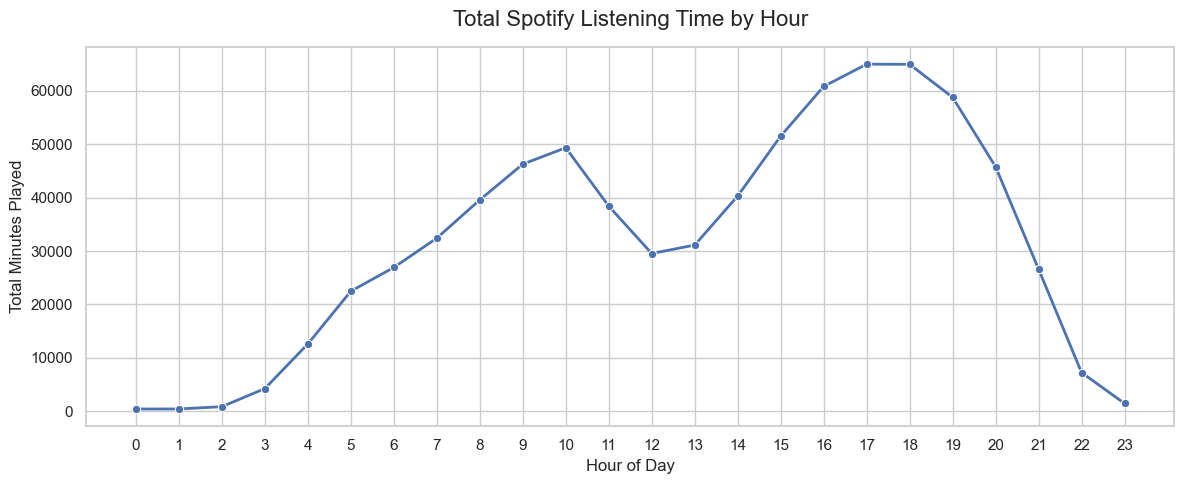

In [15]:
hourly_minutes = (
    df.groupby('hour')['minutes_played']
    .sum()
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    x=hourly_minutes.index,
    y=hourly_minutes.values,
    marker='o',
    linewidth=2
)

plt.title(
    'Total Spotify Listening Time by Hour',
    fontsize=16,
    pad=15
)

plt.xlabel('Hour of Day')
plt.ylabel('Total Minutes Played')

plt.xticks(range(24))

plt.tight_layout()

plt.show()

### Insight

Listening behavior followed a strong daily rhythm, with activity peaking during late afternoon and evening hours.

Very low listening activity during overnight hours suggests that Spotify usage was largely intentional and active rather than passive overnight playback.

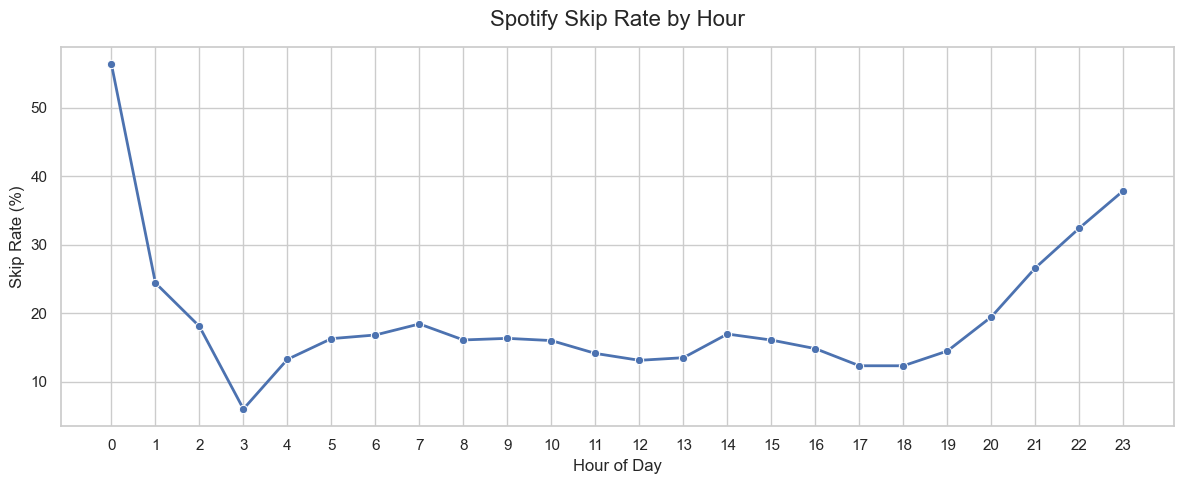

In [16]:
skip_rate_hour = (
    df.groupby('hour')['skipped']
    .mean()
    * 100
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    x=skip_rate_hour.index,
    y=skip_rate_hour.values,
    marker='o',
    linewidth=2
)

plt.title(
    'Spotify Skip Rate by Hour',
    fontsize=16,
    pad=15
)

plt.xlabel('Hour of Day')
plt.ylabel('Skip Rate (%)')

plt.xticks(range(24))

plt.tight_layout()

plt.show()

### Insight

Skip behavior was significantly higher during low-activity hours, particularly around midnight and late-night periods.

This likely reflects more exploratory or less focused listening behavior during those sessions, compared to the more stable engagement patterns observed during peak listening hours.

## 4. Artist & Preference Analysis

This section explores long-term music preference patterns across multiple years of listening history.

The analysis focuses on:

- Most listened-to artists
- Changes in artist preference over time
- Artist dominance by year
- Listening diversity trends

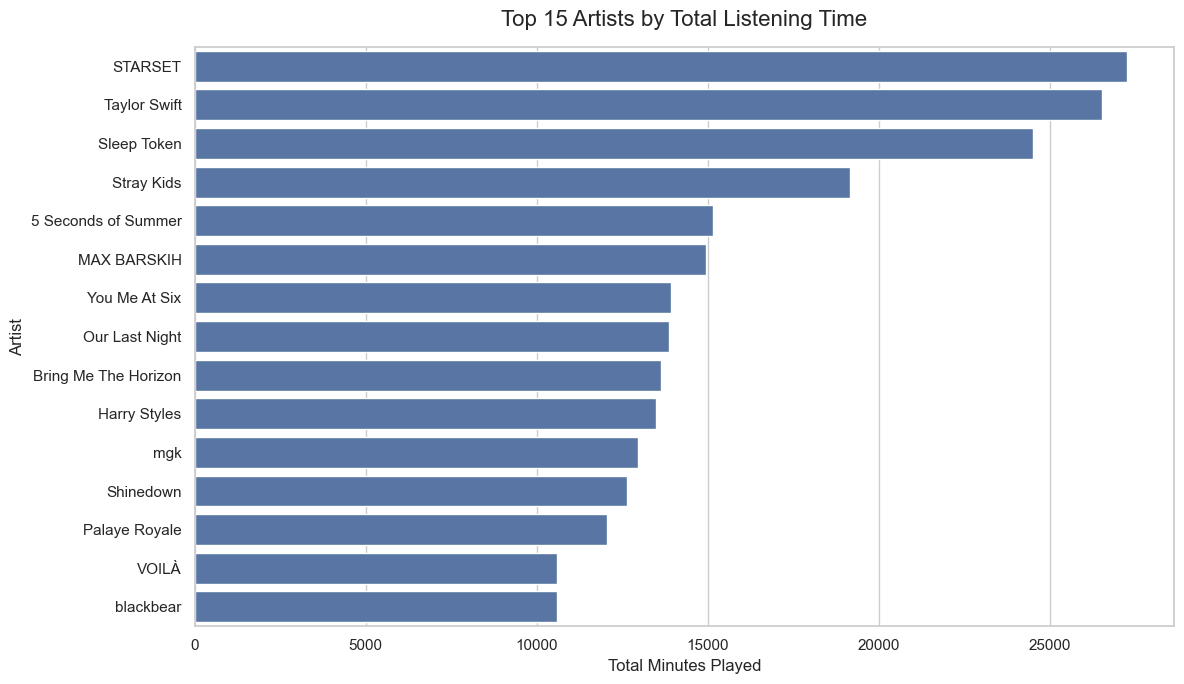

In [17]:
top_artists = (
    df.groupby('artist_name')['minutes_played']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_artists.values,
    y=top_artists.index
)

plt.title(
    'Top 15 Artists by Total Listening Time',
    fontsize=16,
    pad=15
)

plt.xlabel('Total Minutes Played')
plt.ylabel('Artist')

plt.tight_layout()

plt.show()

### Insight

Listening behavior demonstrated strong long-term artist loyalty, with several artists consistently appearing throughout the dataset across multiple years.

At the same time, the distribution was not dominated by a single artist alone, suggesting sustained diversity in listening preferences despite recurring artist affinity.

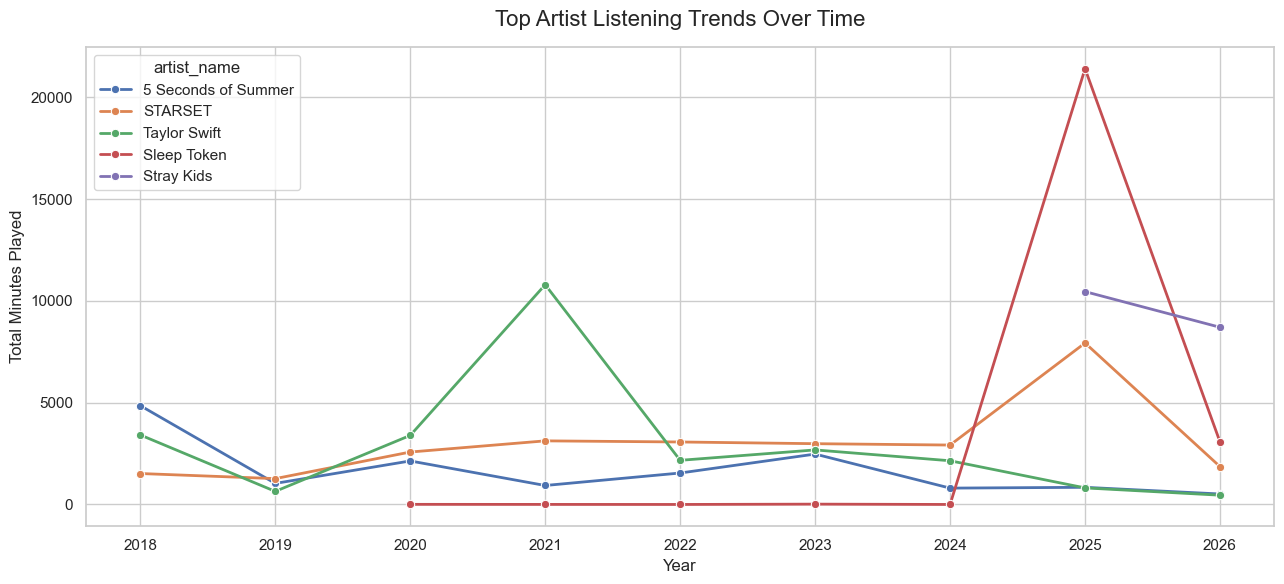

In [18]:
top_5_artists = (
    df.groupby('artist_name')['minutes_played']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

artist_trends = (
    df[df['artist_name'].isin(top_5_artists)]
    .groupby(['year', 'artist_name'])['minutes_played']
    .sum()
    .reset_index()
)

plt.figure(figsize=(13, 6))

sns.lineplot(
    data=artist_trends,
    x='year',
    y='minutes_played',
    hue='artist_name',
    marker='o',
    linewidth=2
)

plt.title(
    'Top Artist Listening Trends Over Time',
    fontsize=16,
    pad=15
)

plt.xlabel('Year')
plt.ylabel('Total Minutes Played')

plt.tight_layout()

plt.show()

### Insight

Artist preference patterns changed significantly across years, revealing distinct listening phases and evolving engagement trends.

While some artists maintained relatively stable listening activity, others demonstrated sharp spikes in engagement during specific periods, suggesting concentrated preference cycles rather than purely stable long-term consumption.

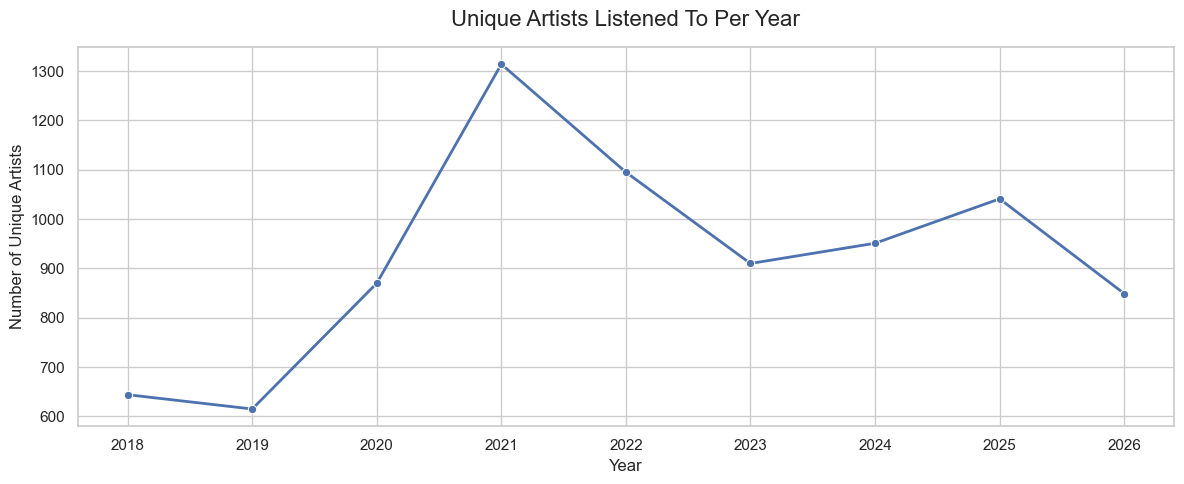

In [19]:
artist_diversity = (
    df.groupby('year')['artist_name']
    .nunique()
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    x=artist_diversity.index,
    y=artist_diversity.values,
    marker='o',
    linewidth=2
)

plt.title(
    'Unique Artists Listened To Per Year',
    fontsize=16,
    pad=15
)

plt.xlabel('Year')
plt.ylabel('Number of Unique Artists')

plt.tight_layout()

plt.show()

### Insight

Even during periods of strong artist concentration, listening diversity remained relatively high overall.

This suggests that increased engagement with specific artists did not necessarily reduce broader music exploration behavior.

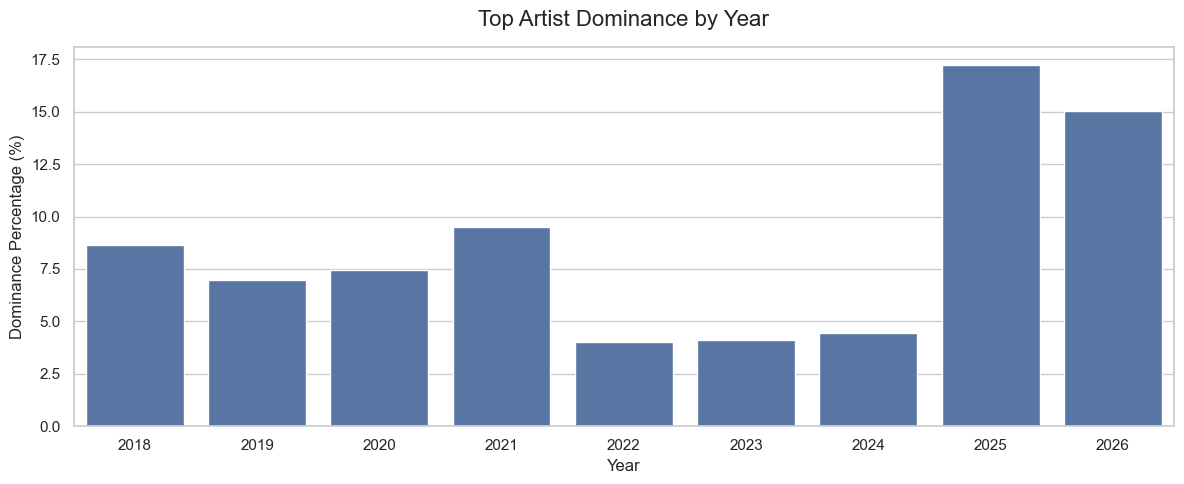

In [20]:
yearly_artist_minutes = (
    df.groupby(['year', 'artist_name'])['minutes_played']
    .sum()
    .reset_index()
)

yearly_totals = (
    df.groupby('year')['minutes_played']
    .sum()
    .reset_index(name='total_year_minutes')
)

dominance = yearly_artist_minutes.merge(
    yearly_totals,
    on='year'
)

dominance['dominance_percent'] = (
    dominance['minutes_played'] /
    dominance['total_year_minutes']
) * 100

top_artist_per_year = (
    dominance.sort_values(
        ['year', 'dominance_percent'],
        ascending=[True, False]
    )
    .groupby('year')
    .head(1)
)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=top_artist_per_year,
    x='year',
    y='dominance_percent'
)

plt.title(
    'Top Artist Dominance by Year',
    fontsize=16,
    pad=15
)

plt.xlabel('Year')
plt.ylabel('Dominance Percentage (%)')

plt.tight_layout()

plt.show()

### Insight

Most years were not heavily dominated by a single artist, indicating relatively balanced listening behavior overall.

However, certain periods demonstrated stronger concentration around individual artists, reflecting temporary but highly engaged listening phases.

## 5. Session Analytics

Listening activity was further analyzed at the session level in order to better understand engagement depth and listening behavior patterns.

This section focuses on:

- Session duration distribution
- Session engagement characteristics
- Listening depth
- Relationships between session duration and skip behavior

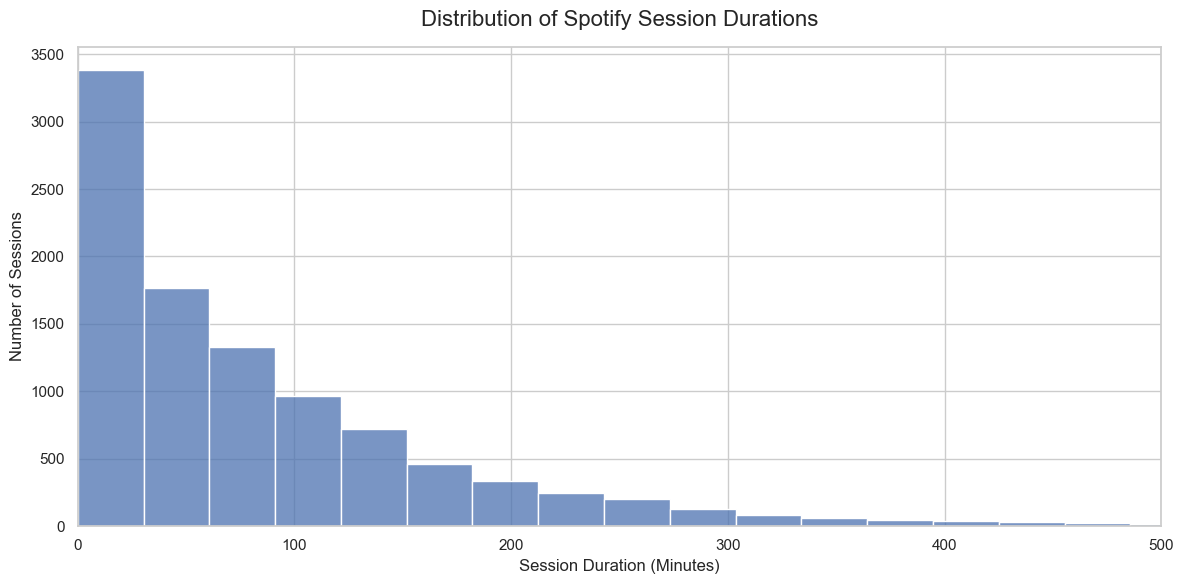

In [21]:
plt.figure(figsize=(12, 6))

sns.histplot(
    session_analysis['session_duration_minutes'],
    bins=30
)

plt.title(
    'Distribution of Spotify Session Durations',
    fontsize=16,
    pad=15
)

plt.xlabel('Session Duration (Minutes)')
plt.ylabel('Number of Sessions')

plt.xlim(0, 500)

plt.tight_layout()

plt.show()

### Insight

Most listening sessions were relatively short-to-medium in duration, while a smaller number of sessions demonstrated extremely long engagement periods.

This long-tail distribution suggests that Spotify usage consisted of both casual listening sessions and highly immersive long-duration engagement behavior.

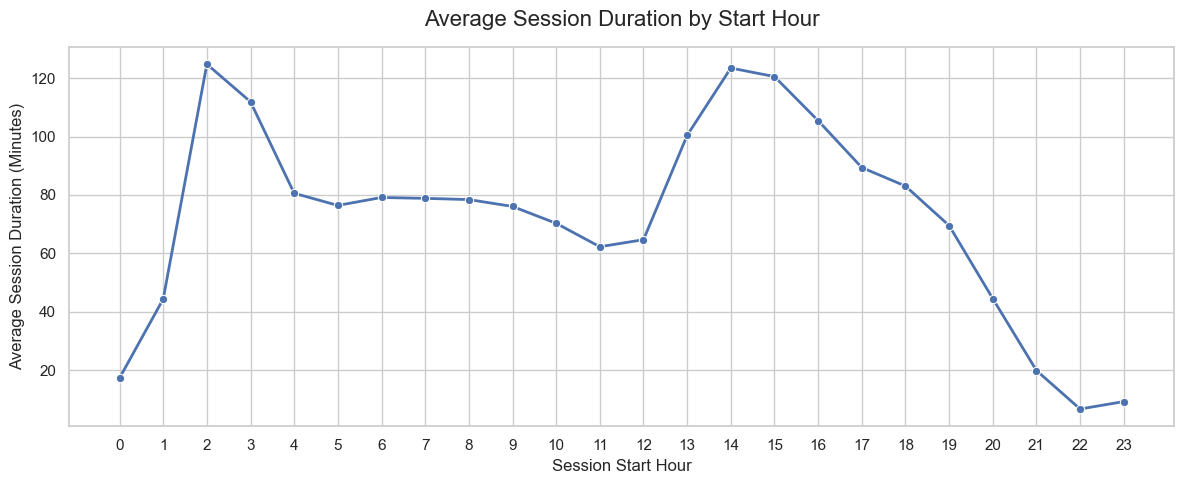

In [22]:
avg_session_by_hour = (
    session_analysis.groupby('start_hour')[
        'session_duration_minutes'
    ]
    .mean()
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    x=avg_session_by_hour.index,
    y=avg_session_by_hour.values,
    marker='o',
    linewidth=2
)

plt.title(
    'Average Session Duration by Start Hour',
    fontsize=16,
    pad=15
)

plt.xlabel('Session Start Hour')
plt.ylabel('Average Session Duration (Minutes)')

plt.xticks(range(24))

plt.tight_layout()

plt.show()

### Insight

Sessions beginning during afternoon and evening hours tended to be significantly longer on average, suggesting stronger engagement during peak listening periods.

Late-night sessions were generally shorter and less consistent, likely reflecting more exploratory or fragmented listening behavior.

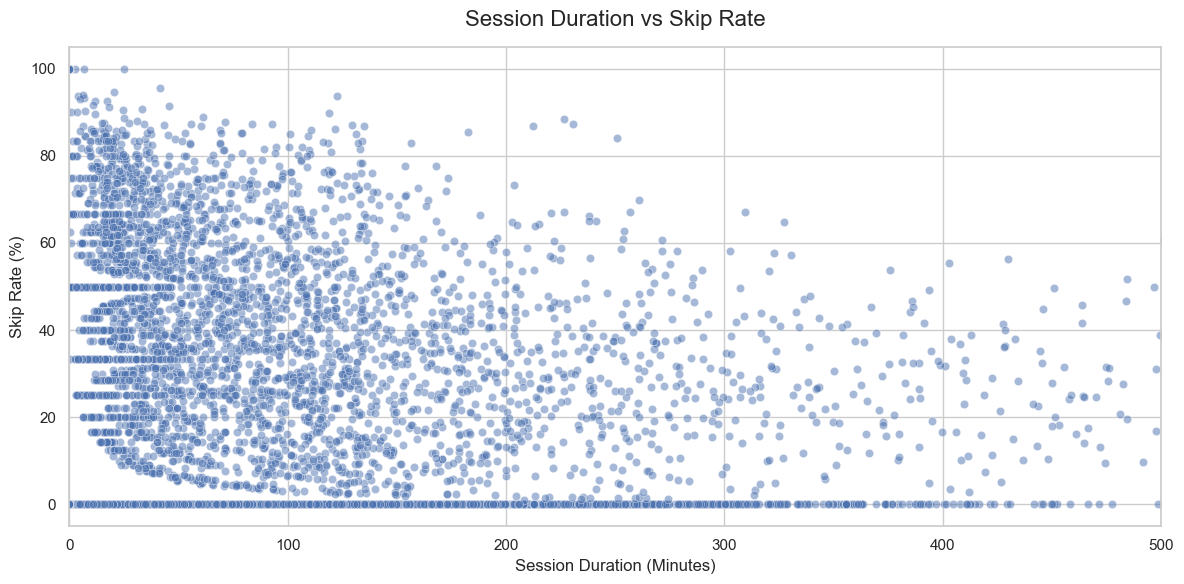

In [23]:
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=session_analysis,
    x='session_duration_minutes',
    y='skip_rate',
    alpha=0.5
)

plt.title(
    'Session Duration vs Skip Rate',
    fontsize=16,
    pad=15
)

plt.xlabel('Session Duration (Minutes)')
plt.ylabel('Skip Rate (%)')

plt.xlim(0, 500)

plt.tight_layout()

plt.show()

### Insight

Short listening sessions demonstrated highly variable skip behavior, ranging from highly focused engagement to extremely exploratory playback behavior.

Longer sessions showed more stable skip behavior overall, suggesting sustained and intentional engagement during extended listening periods.

In [24]:
session_analysis[
    [
        'session_duration_minutes',
        'tracks_played',
        'skip_rate'
    ]
].describe().round(2)

,session_duration_minutes,tracks_played,skip_rate
count,9857.00,9857.00,9857.00
mean,84.26,48.99,15.78
std,91.15,59.82,24.08
min,0.00,1.00,0.00
25%,18.73,11.00,0.00
50%,56.22,31.00,0.00
75%,119.07,67.00,29.31
max,910.73,1313.00,100.00


## 6. Behavioral Segmentation

To better understand listening behavior patterns, listening sessions were grouped into behavioral archetypes using unsupervised machine learning.

KMeans clustering was applied using the following session-level metrics:

- Session duration
- Number of tracks played
- Skip rate

The goal was to identify distinct engagement behaviors across listening sessions rather than treating all sessions as behaviorally identical.

In [25]:
# Features used for clustering
clustering_data = session_analysis[
    [
        'session_duration_minutes',
        'tracks_played',
        'skip_rate'
    ]
].copy()

# Scale features
scaler = StandardScaler()

scaled_features = scaler.fit_transform(clustering_data)

In [26]:
# KMeans clustering
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

session_analysis['cluster'] = kmeans.fit_predict(
    scaled_features
)

session_analysis.head()

,total_minutes,tracks_played,session_start,session_end,start_hour,skip_rate,session_duration_minutes,cluster
session_id,,,,,,,,
0,8.407967,20,2018-03-05 20:35:24+00:00,2018-03-05 21:40:07+00:00,20,0.0,64.716667,1
1,24.323317,8,2018-03-06 05:29:00+00:00,2018-03-06 05:54:39+00:00,5,0.0,25.650000,1
2,73.635117,26,2018-03-06 09:46:09+00:00,2018-03-06 11:19:55+00:00,9,0.0,93.766667,1
3,19.021467,8,2018-03-06 15:18:21+00:00,2018-03-06 15:34:33+00:00,15,0.0,16.200000,1
4,29.873883,15,2018-03-06 16:36:38+00:00,2018-03-06 17:07:27+00:00,16,0.0,30.816667,1


### Clustering Approach

Four clusters were selected in order to balance interpretability and behavioral separation.

The resulting clusters demonstrated clear differences in listening intensity, session duration, and skip behavior, suggesting meaningful segmentation of listening patterns.

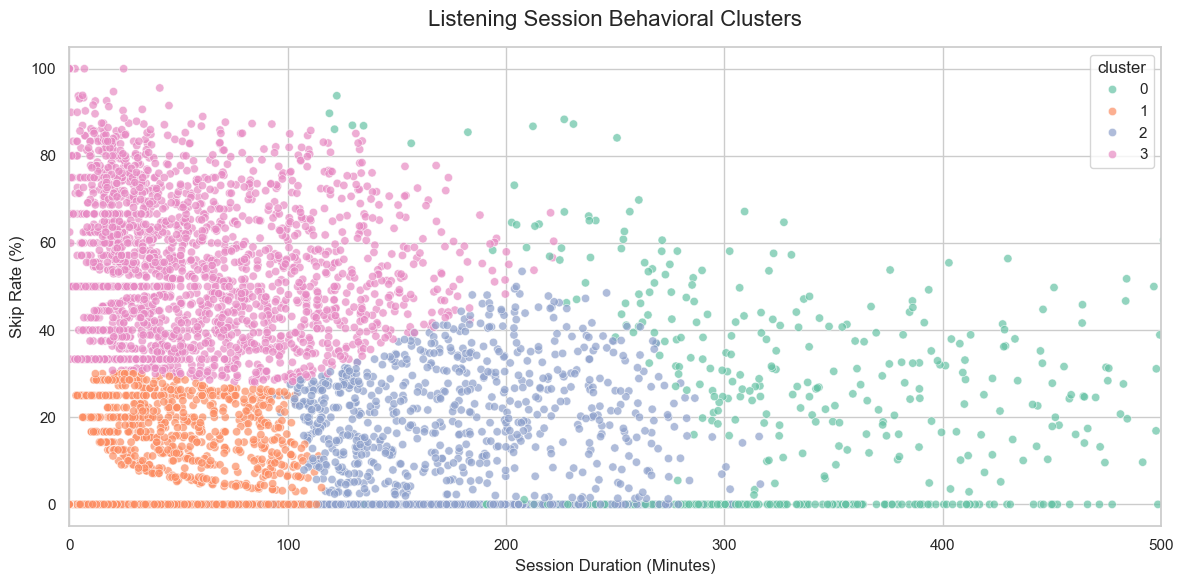

In [27]:
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=session_analysis,
    x='session_duration_minutes',
    y='skip_rate',
    hue='cluster',
    palette='Set2',
    alpha=0.7
)

plt.title(
    'Listening Session Behavioral Clusters',
    fontsize=16,
    pad=15
)

plt.xlabel('Session Duration (Minutes)')
plt.ylabel('Skip Rate (%)')

plt.xlim(0, 500)

plt.tight_layout()

plt.show()

In [28]:
cluster_summary = (
    session_analysis.groupby('cluster')[
        [
            'session_duration_minutes',
            'tracks_played',
            'skip_rate'
        ]
    ]
    .mean()
    .round(2)
)

cluster_summary

,session_duration_minutes,tracks_played,skip_rate
cluster,,,
0,308.76,194.02,15.61
1,31.21,17.28,2.78
2,147.18,81.17,6.32
3,57.76,35.85,55.10


### Cluster Interpretation

The clustering process revealed four distinct listening behavior archetypes:

#### Cluster 0 — Deep Immersion Sessions
Very long sessions with high track counts and relatively low skip rates, suggesting prolonged background or highly immersive listening behavior.

#### Cluster 1 — Focused Listening Sessions
Shorter sessions with extremely low skip rates, indicating highly intentional and stable listening behavior.

#### Cluster 2 — Standard Engagement Sessions
Moderate-duration sessions with balanced skip behavior, representing typical day-to-day listening activity.

#### Cluster 3 — Exploratory Sessions
Sessions characterized by high skip rates and moderate durations, suggesting exploratory or rapidly changing listening behavior.

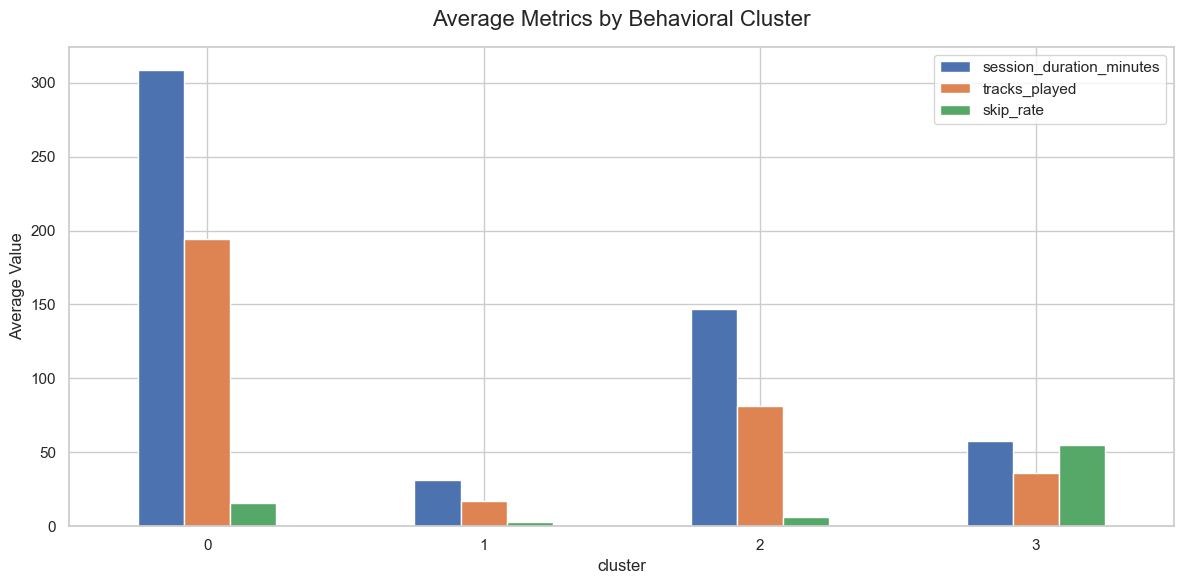

In [29]:
cluster_summary.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title(
    'Average Metrics by Behavioral Cluster',
    fontsize=16,
    pad=15
)

plt.ylabel('Average Value')

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

## 7. Key Findings & Conclusions

This project explored long-term Spotify listening behavior using behavioral analytics, sessionization, and clustering techniques.

Several consistent behavioral patterns emerged throughout the analysis.

### Key Findings

#### Strong Routine-Driven Listening Behavior
Listening activity demonstrated highly consistent temporal patterns, with peak engagement occurring during afternoon and evening hours across multiple years of data.

#### High Long-Term Engagement
Session analysis revealed sustained listening behavior, including many extended listening sessions lasting multiple hours, suggesting deep engagement rather than purely casual playback activity.

#### Stable Diversity Despite Artist Concentration
Although certain artists experienced temporary spikes in listening dominance, overall artist diversity remained consistently high across years.

#### Distinct Behavioral Listening Archetypes
Unsupervised clustering identified four clearly differentiated listening session types, including immersive long-duration sessions, focused low-skip sessions, exploratory high-skip sessions, and standard everyday listening behavior.

#### Exploratory and Intentional Listening Coexisted
The analysis demonstrated that highly engaged listening periods did not necessarily reduce broader exploration behavior, suggesting a balance between artist loyalty and discovery-oriented listening.

## Final Thoughts

This project demonstrates how behavioral analytics techniques can be applied to streaming platform data in order to better understand user engagement patterns, preference evolution, and session-level behavior.

Beyond exploratory analysis, the project incorporated:

- Feature engineering
- Sessionization logic
- Temporal analysis
- Behavioral segmentation
- Clustering techniques
- Data storytelling and interpretation

The workflow reflects many concepts commonly used in product analytics and user behavior analysis within real-world digital platforms.